In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully")

 All libraries imported successfully


In [3]:
"""
Loading the data 
"""

print("Loading data ")


# Load the CSV files
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

print(f" 2023 data: {df_2023.shape[0]} households × {df_2023.shape[1]} days")
print(f" 2024 data: {df_2024.shape[0]} households × {df_2024.shape[1]} days")
print(f"\nFirst 5 household IDs: {df_2023.index[:5].tolist()}")
print(f"First 5 column names (days): {df_2023.columns[:5].tolist()}")

Loading data 
 2023 data: 17547 households × 365 days
 2024 data: 17547 households × 366 days

First 5 household IDs: [22, 42, 56, 58, 64]
First 5 column names (days): ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05']


In [4]:
"""
Verify data quality
"""

print("Data Quality Check")


# Check for missing values
missing_2023 = df_2023.isnull().sum().sum()
missing_2024 = df_2024.isnull().sum().sum()
print(f"Missing values in 2023: {missing_2023}")
print(f"Missing values in 2024: {missing_2024}")

# Check data types
print(f"\nData type of values: {df_2023.dtypes[0]}")

# Basic statistics
all_values = df_2023.values.flatten()
print(f"\n2023 Consumption Statistics:")
print(f"  Min: {all_values.min():.2f}")
print(f"  Max: {all_values.max():.2f}")
print(f"  Mean: {all_values.mean():.2f}")
print(f"  Median: {np.median(all_values):.2f}")

Data Quality Check
Missing values in 2023: 0
Missing values in 2024: 0

Data type of values: float64

2023 Consumption Statistics:
  Min: 0.00
  Max: 1051.74
  Mean: 9.13
  Median: 6.05


In [5]:
"""
Extracting features for clustering
"""

print("Feature Extraction")


# Create features DataFrame
features = pd.DataFrame(index=df_2023.index)

# Basic statistical features
features['mean_consumption'] = df_2023.mean(axis=1)
features['std_consumption'] = df_2023.std(axis=1)
features['max_consumption'] = df_2023.max(axis=1)
features['min_consumption'] = df_2023.min(axis=1)
features['range_consumption'] = features['max_consumption'] - features['min_consumption']

# Coefficient of variation (normalized variability)
features['cv'] = features['std_consumption'] / (features['mean_consumption'] + 1e-6)

# Skewness (pattern asymmetry)
features['skewness'] = df_2023.apply(lambda x: skew(x.dropna()), axis=1)

# Zero values analysis
features['zero_days'] = (df_2023 == 0).sum(axis=1)
features['zero_percentage'] = (features['zero_days'] / df_2023.shape[1]) * 100

# Percentiles
features['p90'] = df_2023.quantile(0.9, axis=1)
features['p10'] = df_2023.quantile(0.1, axis=1)

print(f" Created {len(features.columns)} features for {len(features)} households")
print(f"\nFeatures: {features.columns.tolist()}")

# Show first few rows
print(f"\nFirst 5 households (first 5 features):")
print(features.iloc[:5, :5])

Feature Extraction
 Created 11 features for 17547 households

Features: ['mean_consumption', 'std_consumption', 'max_consumption', 'min_consumption', 'range_consumption', 'cv', 'skewness', 'zero_days', 'zero_percentage', 'p90', 'p10']

First 5 households (first 5 features):
    mean_consumption  std_consumption  max_consumption  min_consumption  \
ID                                                                        
22         11.857921         3.978609           25.944            1.928   
42         14.054819        18.981447           81.248            0.059   
56          5.609575         5.217587           23.488            0.062   
58          9.320200         5.298971           39.773            1.958   
64          2.438655         0.515581            4.400            0.137   

    range_consumption  
ID                     
22             24.016  
42             81.189  
56             23.426  
58             37.815  
64              4.263  


In [6]:
"""
Log transform for skewed features
"""

print("HAandling Skewed Distributions")


# Check skewness before
skew_before = skew(features['mean_consumption'])
print(f"Skewness of mean consumption BEFORE: {skew_before:.2f}")

# Apply log transform
features['mean_consumption_log'] = np.log1p(features['mean_consumption'])
features['max_consumption_log'] = np.log1p(features['max_consumption'])

# Check skewness a fter
skew_after = skew(features['mean_consumption_log'])
print(f"Skewness of mean consumption AFTER: {skew_after:.2f}")

# Identify constant and extreme households
std_per_household = df_2023.std(axis=1)
constant_households = std_per_household[std_per_household == 0].index.tolist()
extreme_households = features[features['mean_consumption'] > 50].index.tolist()

print(f"\nSpecial households identified:")
print(f"   Constant households (no variation): {len(constant_households)}")
print(f"   Extreme households (avg > 50): {len(extreme_households)}")

HAandling Skewed Distributions
Skewness of mean consumption BEFORE: 5.14
Skewness of mean consumption AFTER: -0.08

Special households identified:
   Constant households (no variation): 154
   Extreme households (avg > 50): 123


In [7]:
"""
Data Clenaing
Purpose: Handle constant households and prepare data for clustering
"""


print("Data Clenaing")


features_clean = features.copy()


#  Handling Constant Households (std = 0)

print("\n1. Handling constant households...")
constant_mask = features_clean['std_consumption'] == 0
constant_count = constant_mask.sum()
print(f"   Found {constant_count} constant households")

if constant_count > 0:
    # Add tiny noise to constant households
    np.random.seed(42)
    features_clean.loc[constant_mask, 'std_consumption'] = 0.0001
    features_clean.loc[constant_mask, 'cv'] = 0.0001
    print(f"   Added tiny noise to preserve clusterability")


#  Verify no infinite or NaN values

print("\n2. Verifying data quality...")
print(f"   NaN values: {features_clean.isnull().sum().sum()}")
print(f"   Infinite values: {np.isinf(features_clean).sum().sum()}")
print(f"    Data is clean and ready")


print("\n3. Dataset summary after cleaning:")
print(f"   Total households: {len(features_clean)}")
print(f"   Features: {len(features_clean.columns)}")
print(f"   Memory usage: {features_clean.memory_usage(deep=True).sum() / 1024:.1f} KB")


Data Clenaing

1. Handling constant households...
   Found 154 constant households
   Added tiny noise to preserve clusterability

2. Verifying data quality...
   NaN values: 154
   Infinite values: 0
    Data is clean and ready

3. Dataset summary after cleaning:
   Total households: 17547
   Features: 13
   Memory usage: 1919.2 KB


Feature Normalization
Using features: ['mean_consumption_log', 'std_consumption', 'cv', 'zero_percentage', 'skewness', 'range_consumption']

 Scaled 6 features

Feature statistics after scaling:
  mean_consumption_log: mean=0.00, std=1.00
  std_consumption: mean=0.00, std=1.00
  cv: mean=-0.00, std=1.00
  zero_percentage: mean=0.00, std=1.00
  skewness: mean=-0.00, std=1.00
  range_consumption: mean=0.00, std=1.00


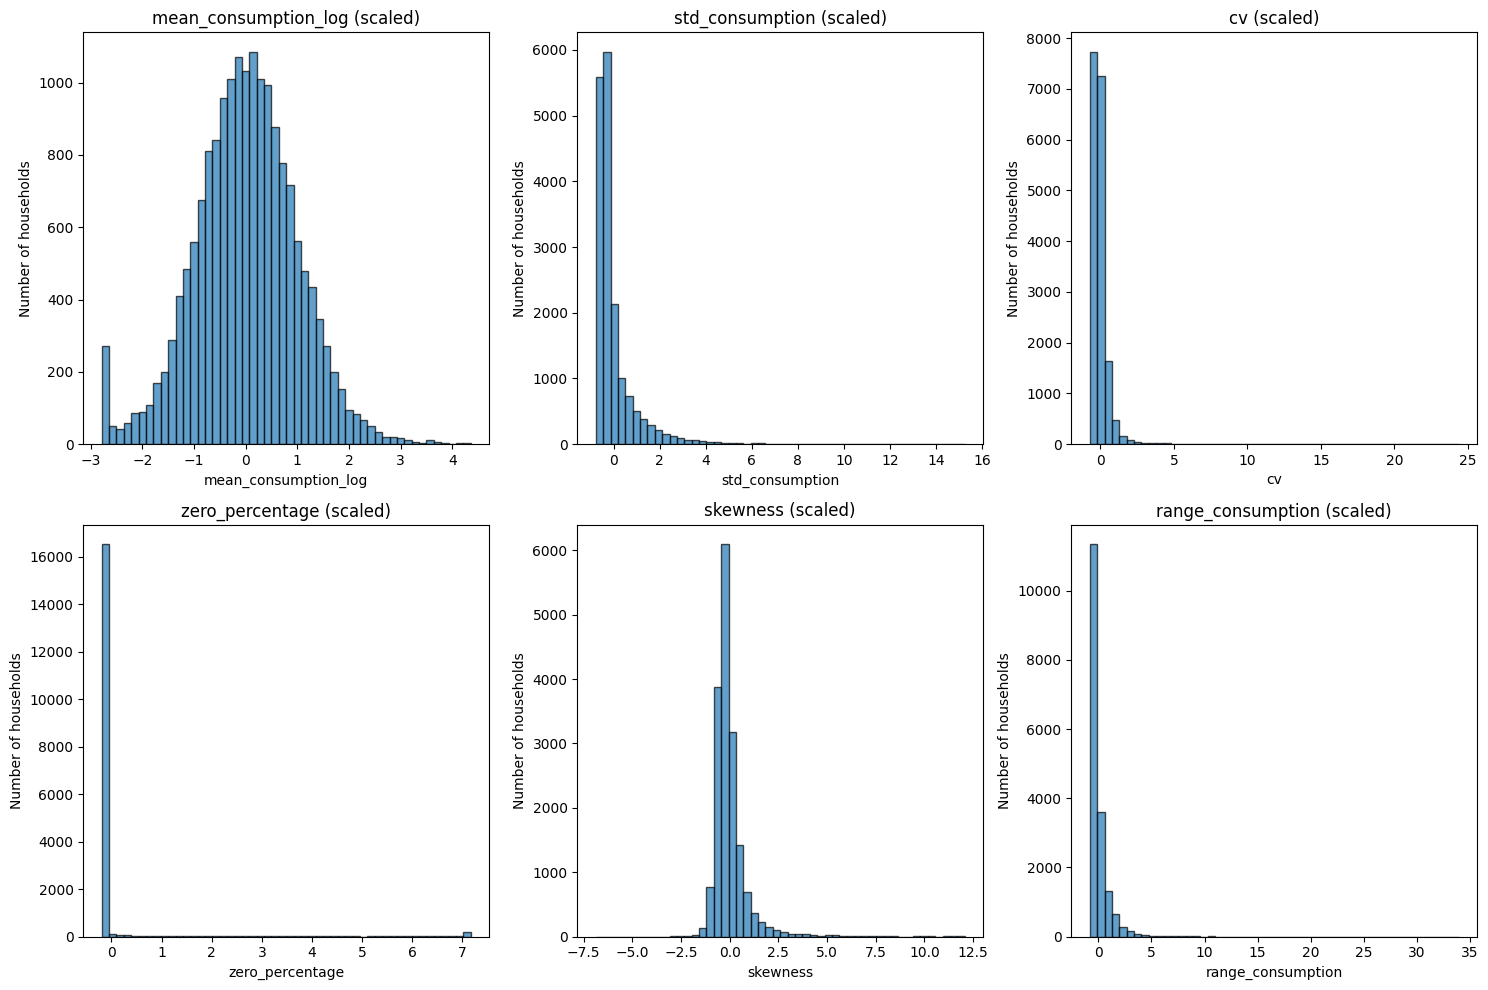

In [9]:
"""
Normalizing features for clustering
"""

print("Feature Normalization")


from sklearn.preprocessing import StandardScaler

# Selecting features for clustering
cluster_features = [
    'mean_consumption_log', 
    'std_consumption', 
    'cv', 
    'zero_percentage', 
    'skewness', 
    'range_consumption'
]

# Checking if all features exist
missing_features = [f for f in cluster_features if f not in features_clean.columns]
if missing_features:
    print(f" Warning: Missing features: {missing_features}")
    print("Using available features only...")
    cluster_features = [f for f in cluster_features if f in features_clean.columns]

print(f"Using features: {cluster_features}")

# Normalize using StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_clean[cluster_features])
features_scaled = pd.DataFrame(
    features_scaled, 
    index=features_clean.index,
    columns=cluster_features
)

print(f"\n Scaled {len(cluster_features)} features")
print(f"\nFeature statistics after scaling:")
for col in cluster_features:
    print(f"  {col}: mean={features_scaled[col].mean():.2f}, std={features_scaled[col].std():.2f}")

# Visualize distributions after scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cluster_features):
    axes[i].hist(features_scaled[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of households')
    axes[i].set_title(f'{col} (scaled)')

plt.tight_layout()
plt.show()


In [10]:
"""
Fixing NAN before clustering
"""

print("Checking for NaN values")


# Check for NaN in features_scaled
nan_count = features_scaled.isnull().sum().sum()
print(f"NaN values in features_scaled: {nan_count}")

if nan_count > 0:
    print("\n Columns with NaN:")
    nan_cols = features_scaled.columns[features_scaled.isnull().any()].tolist()
    for col in nan_cols:
        nan_rows = features_scaled[col].isnull().sum()
        print(f"   {col}: {nan_rows} NaN values")
    
    # Option 1: Remove rows with NaN (if few)
    print(f"\n Option 1: Remove rows with NaN")
    features_scaled_clean = features_scaled.dropna()
    print(f"   Removed {nan_count} values, {len(features_scaled_clean)} rows remaining")
    
    # Option 2: Fill NaN with column means (better if many rows)
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    features_scaled_clean = pd.DataFrame(
        imputer.fit_transform(features_scaled),
        index=features_scaled.index,
        columns=features_scaled.columns
    )
    print(f"\n Option 2: Fill NaN with column means")
    print(f"   NaN after fix: {features_scaled_clean.isnull().sum().sum()}")
    
    # Replace original with clean version
    features_scaled = features_scaled_clean


Checking for NaN values
NaN values in features_scaled: 154

 Columns with NaN:
   skewness: 154 NaN values

 Option 1: Remove rows with NaN
   Removed 154 values, 17393 rows remaining

 Option 2: Fill NaN with column means
   NaN after fix: 0


Finding optimal number of clusters

Testing k from 2 to 14...
----------------------------------------------------------------------
k     Inertia         Silhouette      Davies-Bouldin 
----------------------------------------------------------------------
2     80193           0.5006          0.9505         
3     57834           0.5512          0.8492         
4     47056           0.5511          0.7551         
5     38897           0.3267          0.8763         
6     33331           0.3214          0.8833         
7     28664           0.3317          0.8619         
8     26140           0.3092          0.9072         
9     24207           0.3110          0.9107         
10    22269           0.3099          0.8156         
11    20545           0.3111          0.7953         
12    19210           0.3220          0.8218         
13    17638           0.2824          0.8461         
14    16550           0.2839          0.8573         


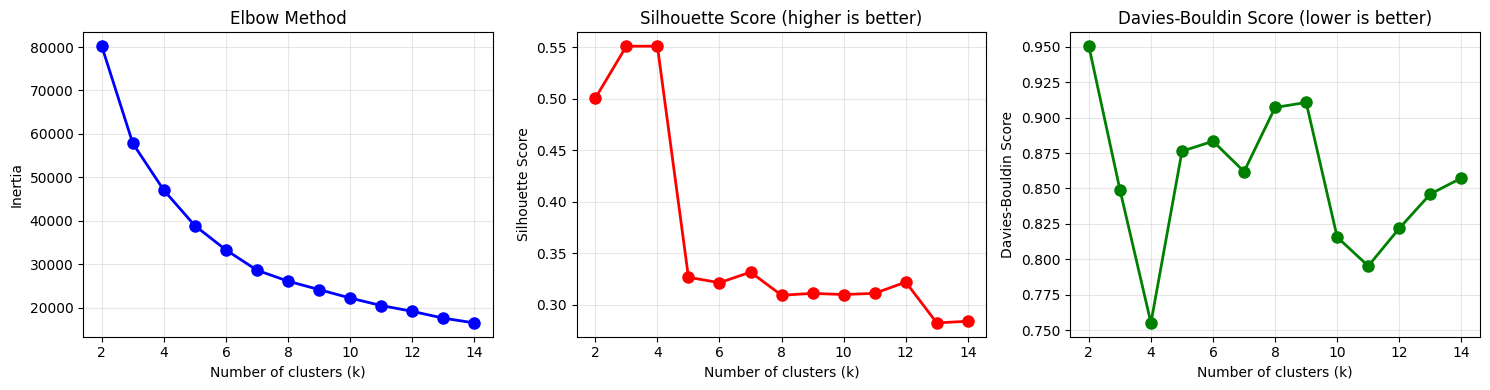

Best k by Silhouette Score: 3 (score: 0.5512)
Best k by Davies-Bouldin: 4 (score: 0.7551)


In [11]:
"""
Finding optimal k value
"""

print("Finding optimal number of clusters")


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Testing different values of k
k_range = range(2, 15)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []

print("\nTesting k from 2 to 14...")
print("-"*70)
print(f"{'k':<5} {'Inertia':<15} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-"*70)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(features_scaled, kmeans.labels_)
    db_score = davies_bouldin_score(features_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    
    print(f"{k:<5} {kmeans.inertia_:<15.0f} {sil_score:<15.4f} {db_score:<15.4f}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', markersize=8, linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin Score
axes[2].plot(k_range, davies_bouldin_scores, 'go-', markersize=8, linewidth=2)
axes[2].set_xlabel('Number of clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (lower is better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best k
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_db = k_range[np.argmin(davies_bouldin_scores)]


print(f"Best k by Silhouette Score: {best_k_silhouette} (score: {max(silhouette_scores):.4f})")
print(f"Best k by Davies-Bouldin: {best_k_db} (score: {min(davies_bouldin_scores):.4f})")



In [12]:
"""
Performing final clustering with k = 4
"""

print(f" Final clustering with  k = 4")


# Perform KMeans clustering with k=4
optimal_k = 4  # Using 4 based on Davies-Bouldin score

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(features_scaled)

# Add cluster labels to features DataFrame
features_clean['cluster'] = cluster_labels

# Showing cluster distribution
print("\n Cluster sizes:")
cluster_counts = features_clean['cluster'].value_counts().sort_index()
for cluster_id in range(optimal_k):
    count = cluster_counts[cluster_id]
    percentage = (count / len(features_clean)) * 100
    print(f"  Cluster {cluster_id}: {count} households ({percentage:.1f}%)")


# Analyze what each cluster represents


print("CLUSTER CHARACTERISTICS")


# Calculate mean values for each cluster
cluster_profiles = features_clean.groupby('cluster')[cluster_features].mean()
print("\nAverage feature values per cluster:")
print(cluster_profiles.round(3))

# Interpreting each cluster
print("\n CLUSTER INTERPRETATION:")
print("-"*50)

for cluster_id in range(optimal_k):
    profile = cluster_profiles.loc[cluster_id]
    
    # Interpret based on features
    if profile['mean_consumption_log'] > 2:
        usage = "HIGH"
    elif profile['mean_consumption_log'] > 1:
        usage = "MEDIUM"
    else:
        usage = "LOW"
    
    if profile['zero_percentage'] > 50:
        vacancy = " (mostly vacant)"
    elif profile['zero_percentage'] > 20:
        vacancy = " (frequently vacant)"
    else:
        vacancy = ""
    
    print(f"\n  Cluster {cluster_id}: {usage} consumption{vacancy}")
    print(f"    • Households: {cluster_counts[cluster_id]}")
    print(f"    • Mean consumption: {np.expm1(profile['mean_consumption_log']):.1f} kWh")
    print(f"    • Zero days: {profile['zero_percentage']:.1f}%")
    print(f"    • Volatility (std): {profile['std_consumption']:.1f}")


# Save cluster assignments

import os
os.makedirs('../outputs', exist_ok=True)

cluster_assignments = pd.DataFrame({
    'household_id': features_clean.index,
    'cluster': cluster_labels
})
cluster_assignments.to_csv('../outputs/cluster_assignments.csv', index=False)


 Final clustering with  k = 4

 Cluster sizes:
  Cluster 0: 444 households (2.5%)
  Cluster 1: 14620 households (83.3%)
  Cluster 2: 66 households (0.4%)
  Cluster 3: 2417 households (13.8%)
CLUSTER CHARACTERISTICS

Average feature values per cluster:
         mean_consumption_log  std_consumption      cv  zero_percentage  \
cluster                                                                   
0                       0.512            1.725   1.415           72.715   
1                       1.928            2.794   0.446            0.366   
2                       0.143            2.528  10.441           85.392   
3                       3.075           15.474   0.750            1.206   

         skewness  range_consumption  
cluster                               
0           2.875              9.021  
1           1.044             16.197  
2          13.398             43.330  
3           1.294             77.257  

 CLUSTER INTERPRETATION:
-------------------------------------

Cluster Visualization


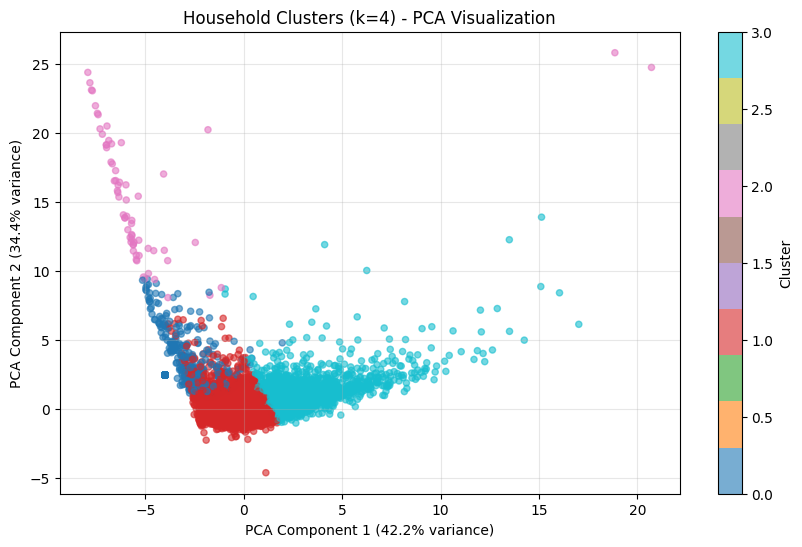

Average Consumption Pattern per cluster


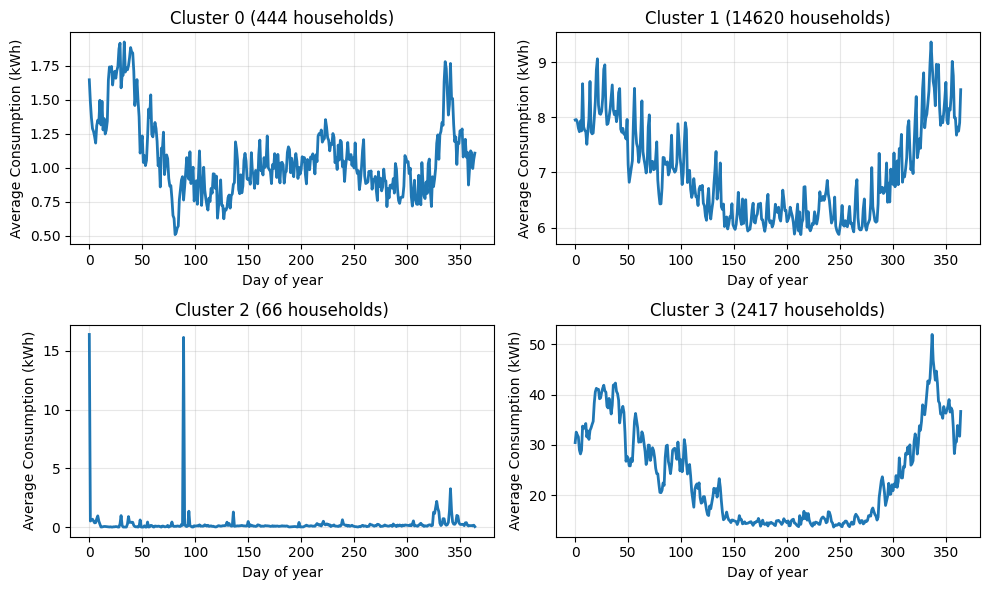

In [14]:
"""
Visualizing clusters
"""

print("Cluster Visualization")


from sklearn.decomposition import PCA

# PCA for 2D visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Plot clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                      c=cluster_labels, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'Household Clusters (k=4) - PCA Visualization')
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/cluster_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot average consumption patterns per cluster

print("Average Consumption Pattern per cluster")


fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i in range(4):
    cluster_households = features_clean[features_clean['cluster'] == i].index
    if len(cluster_households) > 0:
        # Get average consumption pattern for this cluster
        cluster_pattern = df_2023.loc[cluster_households].mean(axis=0)
        axes[i].plot(cluster_pattern.values, linewidth=2)
        axes[i].set_title(f'Cluster {i} ({len(cluster_households)} households)')
        axes[i].set_xlabel('Day of year')
        axes[i].set_ylabel('Average Consumption (kWh)')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/cluster_patterns.png', dpi=150, bbox_inches='tight')
plt.show()




Clustering Features

 Loading data...
 Loaded 17547 households with cluster labels

 Calculating 6 clustering features...
 Calculated 6 features for 17547 households

 Cluster sizes:
   Cluster 0: 444 households
   Cluster 1: 14620 households
   Cluster 2: 66 households
   Cluster 3: 2417 households

 Creating Figure 1: Individual bar charts...


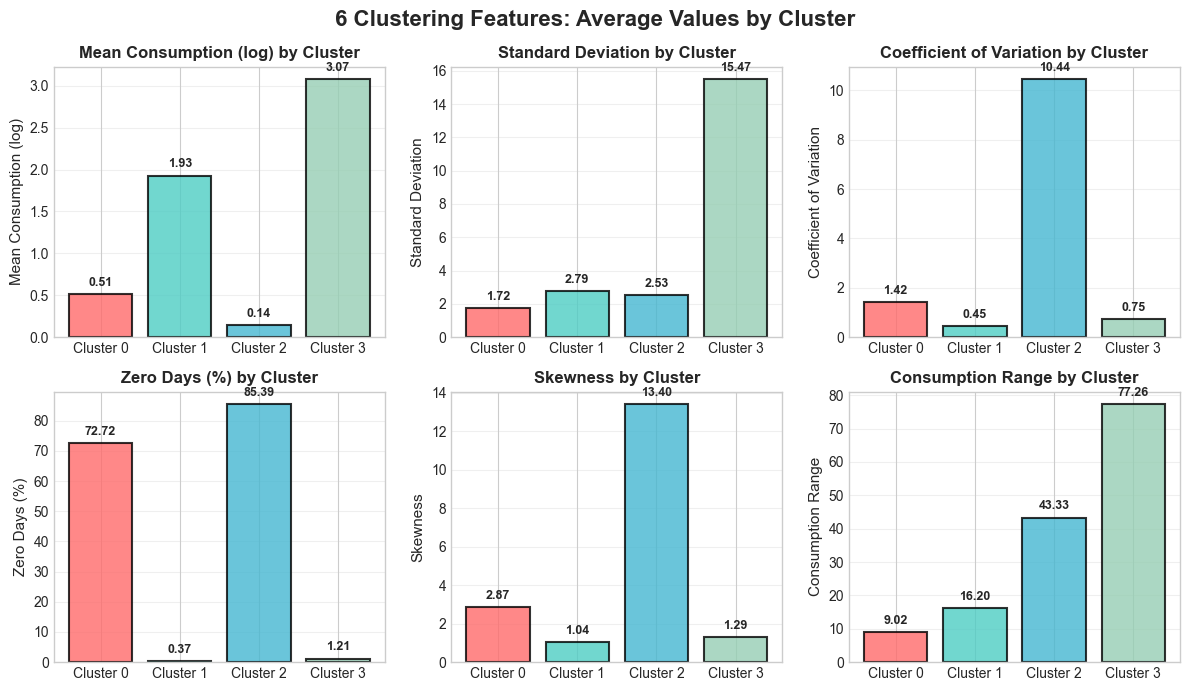

 Saved: ../outputs/clustering_features_bar_charts.png

 Creating Figure 2: Grouped bar chart...


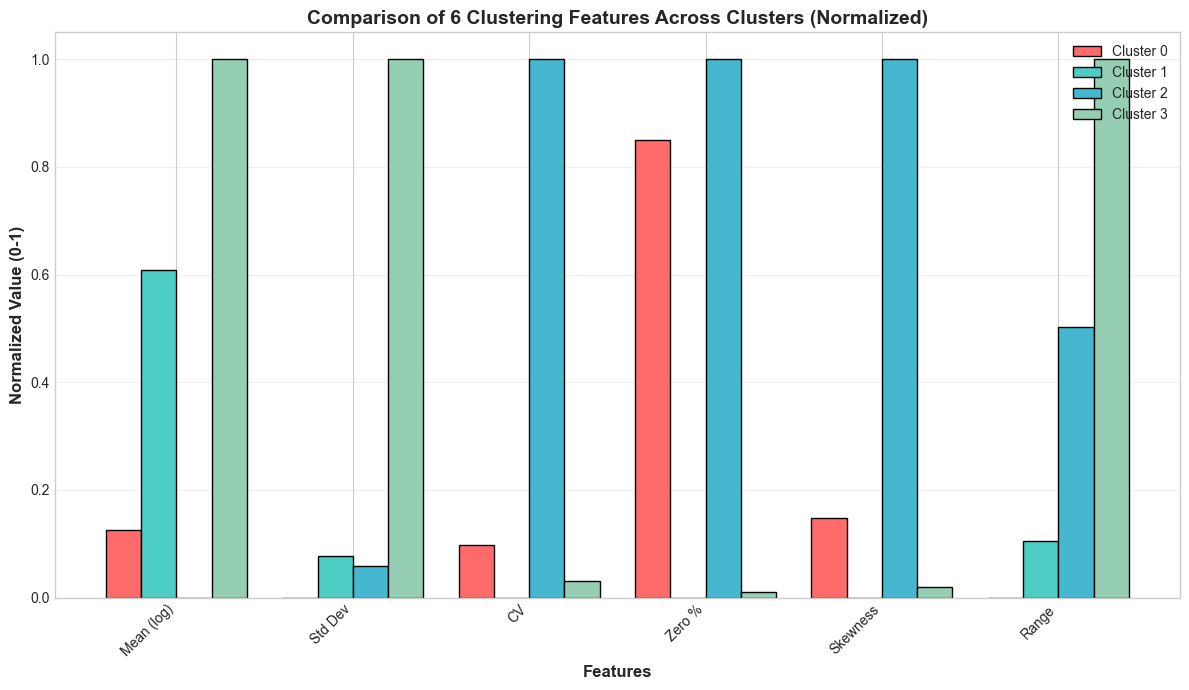


 Creating Figure 3: Horizontal bar chart...


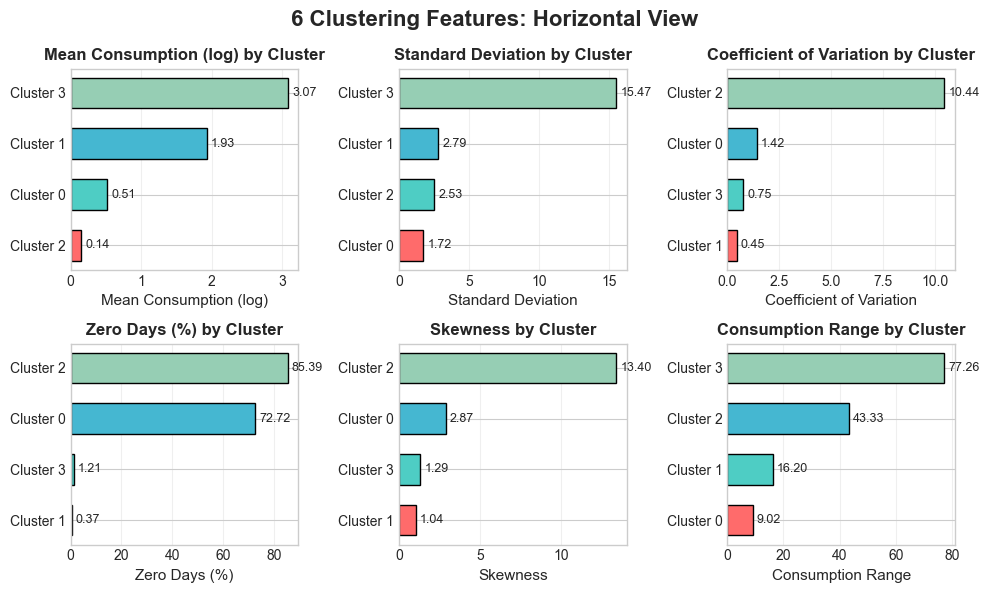

 Saved: ../outputs/clustering_features_horizontal_bars.png
 SUMMARY TABLE: Feature Averages by Cluster
         Mean (log)  Std Dev       CV   Zero %  Skewness    Range
cluster                                                          
0            0.5121   1.7246   1.4150  72.7150    2.8748   9.0210
1            1.9282   2.7937   0.4464   0.3658    1.0439  16.1973
2            0.1429   2.5281  10.4410  85.3923   13.3977  43.3303
3            3.0749  15.4738   0.7500   1.2055    1.2943  77.2573
 CLUSTER INTERPRETATION BASED ON FEATURES

Cluster 0: LOW/VACANT: Low mean, high zero % → Often empty homes
   • Mean consumption: 0.51 (log scale)
   • Standard deviation: 1.72
   • Zero days: 72.7%
   • Households: 444

Cluster 1: MEDIUM: Balanced features → Typical household
   • Mean consumption: 1.93 (log scale)
   • Standard deviation: 2.79
   • Zero days: 0.4%
   • Households: 14620

Cluster 2: INTERMITTENT: Very high CV, moderate zero % → Vacation/seasonal homes
   • Mean consumption: 0.1

In [15]:
"""
Visulaizing 6 clusters
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


print("Clustering Features")


#Loading data
print("\n Loading data...")

# Load original 2023 data
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)

# Load cluster assignments
cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
df_clusters = cluster_assignments.copy()

print(f" Loaded {len(df_clusters)} households with cluster labels")


print("\n Calculating 6 clustering features...")

# Create features DataFrame
features = pd.DataFrame(index=df_2023.index)

#  mean_consumption_log (log-transformed average)
features['mean_consumption'] = df_2023.mean(axis=1)
features['mean_consumption_log'] = np.log1p(features['mean_consumption'])

#  std_consumption (standard deviation)
features['std_consumption'] = df_2023.std(axis=1)

#  cv (coefficient of variation)
features['cv'] = features['std_consumption'] / (features['mean_consumption'] + 1e-6)

#  zero_percentage (percentage of zero consumption days)
features['zero_days'] = (df_2023 == 0).sum(axis=1)
features['zero_percentage'] = (features['zero_days'] / df_2023.shape[1]) * 100

# skewness (asymmetry of consumption pattern)
from scipy.stats import skew
features['skewness'] = df_2023.apply(lambda x: skew(x.dropna()), axis=1)

#  range_consumption (max - min)
features['range_consumption'] = df_2023.max(axis=1) - df_2023.min(axis=1)

# Add cluster labels
features['cluster'] = features.index.map(
    dict(zip(df_clusters['household_id'], df_clusters['cluster']))
)

# Handle any NaN clusters
features = features.dropna(subset=['cluster'])
features['cluster'] = features['cluster'].astype(int)

print(f" Calculated 6 features for {len(features)} households")


feature_info = {
    'mean_consumption_log': 'Mean Consumption (log)',
    'std_consumption': 'Standard Deviation',
    'cv': 'Coefficient of Variation',
    'zero_percentage': 'Zero Days (%)',
    'skewness': 'Skewness',
    'range_consumption': 'Consumption Range'
}

# Calculate mean values per cluster
cluster_means = features.groupby('cluster')[list(feature_info.keys())].mean()

# Get cluster sizes
cluster_sizes = features['cluster'].value_counts().sort_index()
print("\n Cluster sizes:")
for c in range(4):
    print(f"   Cluster {c}: {cluster_sizes[c]} households")


print("\n Creating Figure 1: Individual bar charts...")

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, (feature, display_name) in enumerate(feature_info.items()):
    means = cluster_means[feature]
    x_pos = range(len(means))
    
    bars = axes[i].bar(x_pos, means, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[i].set_xticks(x_pos)
    axes[i].set_xticklabels([f'Cluster {c}' for c in means.index])
    axes[i].set_ylabel(display_name, fontsize=11)
    axes[i].set_title(f'{display_name} by Cluster', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, means):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(means),
                    f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('6 Clustering Features: Average Values by Cluster', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/clustering_features_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: ../outputs/clustering_features_bar_charts.png")


print("\n Creating Figure 2: Grouped bar chart...")

# Normalize features for fair comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(cluster_means_norm.columns))
width = 0.2

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
feature_names_short = ['Mean (log)', 'Std Dev', 'CV', 'Zero %', 'Skewness', 'Range']

for i, cluster_id in enumerate(cluster_means_norm.index):
    values = cluster_means_norm.loc[cluster_id].values
    bars = ax.bar(x + i*width, values, width, label=f'Cluster {cluster_id}', color=colors[i], edgecolor='black')

ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Comparison of 6 Clustering Features Across Clusters (Normalized)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feature_names_short, fontsize=10, rotation=45, ha='right')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/clustering_features_grouped_bars.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n Creating Figure 3: Horizontal bar chart...")

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

feature_names_long = ['Mean Consumption (log)', 'Standard Deviation', 'Coefficient of Variation', 
                      'Zero Days (%)', 'Skewness', 'Consumption Range']

for i, (feature, display_name) in enumerate(feature_info.items()):
    means = cluster_means[feature].sort_values()
    y_pos = range(len(means))
    
    colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    axes[i].barh(y_pos, means.values, color=colors_bar, edgecolor='black', height=0.6)
    axes[i].set_yticks(y_pos)
    axes[i].set_yticklabels([f'Cluster {c}' for c in means.index])
    axes[i].set_xlabel(display_name, fontsize=11)
    axes[i].set_title(f'{display_name} by Cluster', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for j, v in enumerate(means.values):
        axes[i].text(v + 0.02 * max(means), j, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('6 Clustering Features: Horizontal View', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/clustering_features_horizontal_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: ../outputs/clustering_features_horizontal_bars.png")



print(" SUMMARY TABLE: Feature Averages by Cluster")


summary_table = cluster_means.round(4)
summary_table.columns = ['Mean (log)', 'Std Dev', 'CV', 'Zero %', 'Skewness', 'Range']
print(summary_table.to_string())



print(" CLUSTER INTERPRETATION BASED ON FEATURES")



interpretations = {
    0: "LOW/VACANT: Low mean, high zero % → Often empty homes",
    1: "MEDIUM: Balanced features → Typical household",
    2: "INTERMITTENT: Very high CV, moderate zero % → Vacation/seasonal homes",
    3: "HIGH: High mean, high range → High consumption households"
}

for cluster_id in range(4):
    print(f"\nCluster {cluster_id}: {interpretations[cluster_id]}")
    print(f"   • Mean consumption: {cluster_means.loc[cluster_id, 'mean_consumption_log']:.2f} (log scale)")
    print(f"   • Standard deviation: {cluster_means.loc[cluster_id, 'std_consumption']:.2f}")
    print(f"   • Zero days: {cluster_means.loc[cluster_id, 'zero_percentage']:.1f}%")
    print(f"   • Households: {cluster_sizes[cluster_id]}")



print("\nOutput files:")
print("   1. ../outputs/clustering_features_bar_charts.png")
print("   2. ../outputs/clustering_features_grouped_bars.png")
print("   3. ../outputs/clustering_features_horizontal_bars.png")